# Resultados comparativos — Baseline vs QLoRA

Notebook de **documentação experimental** do TCC. Cada seção explica **o que**, **por que** e **como medir**.

## Pipeline (5 fases)

| Fase | Componente | Motivo |
|------|------------|--------|
| 1 | Detectron2 + crop + CLAHE | Isola o hidrômetro e melhora contraste dos roletes |
| 2 | Label Studio (+ autolabel inicial) | Revisão humana dos labels JSON |
| 3 | QLoRA Florence-2-large | Aprende leitura estruturada com ~500 amostras |
| 4 | FastAPI / Streamlit | Deploy para demonstração |
| 5 | Métricas (este notebook) | Quantifica acurácia, precisão e CER |

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

PROJECT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((p for p in PROJECT_CANDIDATES if (p / "src" / "hidrometro").exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Abra o notebook a partir de vit-tcc-qlora-hidrometro/ ou notebooks/.")

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Markdown, display

from hidrometro.autolabel.label_studio import load_meter_label
from hidrometro.config import load_yaml, resolve_path
from hidrometro.evaluation.metrics import (
    compute_metrics,
    metrics_summary_table,
    run_vlm_evaluation,
    samples_to_dicts,
)
from hidrometro.vlm.inference import VLMInference

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 4), "font.size": 11})

print(f"Projeto: {PROJECT_ROOT}")
print(f"CUDA: {torch.cuda.is_available()}")

SPLIT = "test"
EVAL_LIMIT = 0  # 0 = todas as amostras do split

c:\Users\Niccolas\Downloads\TrabalhoDetecaoObjetos\vit-tcc-qlora-hidrometro\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Projeto: c:\Users\Niccolas\Downloads\TrabalhoDetecaoObjetos\vit-tcc-qlora-hidrometro
Kernel correto: sim
CUDA: True


## 1. Ambiente e artefatos

Verificamos versões de software e paths dos artefatos treinados.

**Por que importa:** resultados dependem de transformers 4.56.x, CUDA e adaptador LoRA em `artifacts/lora_adapter/`.

In [2]:
import transformers

paths = load_yaml("paths.yaml")
qlora_cfg = load_yaml("qlora.yaml")
adapter_dir = resolve_path(paths["output"]["lora_adapter"])
crops_dir = resolve_path(paths["output"]["crops"]) / SPLIT
validated_dir = resolve_path(paths["output"]["autolabel_validated"]) / SPLIT

env_rows = [
    ("Python", sys.version.split()[0]),
    ("PyTorch", torch.__version__),
    ("Transformers", transformers.__version__),
    ("CUDA", torch.cuda.is_available()),
    ("GPU", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "—"),
    ("Modelo base", qlora_cfg["model"]["name"]),
    ("Adaptador LoRA", str(adapter_dir)),
    ("Split avaliado", SPLIT),
]
display(pd.DataFrame(env_rows, columns=["item", "valor"]))

,item,valor
0,Python,3.14.2
1,PyTorch,2.11.0+cu128
2,Transformers,4.56.2
3,CUDA,True
4,GPU,NVIDIA GeForce RTX 5070 Ti Laptop GPU
5,Modelo base,microsoft/Florence-2-large
6,Adaptador LoRA,C:\Users\Niccolas\Downloads\TrabalhoDetecaoObj...
7,Split avaliado,test


## 2. Dataset SFT

Labels validados manualmente no Label Studio compõem o ground truth.

| Split | Amostras | Uso |
|-------|----------|-----|
| train | 503 | Treino LoRA |
| val | 144 | Seleção do melhor checkpoint (eval_loss) |
| test | 72 | **Métricas finais** — nunca usado no treino |

In [3]:
sft_dir = resolve_path(paths["output"]["sft"])
gt: dict[str, dict] = {}
for label_path in sorted(validated_dir.glob("*.json")):
    gt[label_path.stem] = load_meter_label(label_path)

sft_counts = {}
for split_name in ["train", "val", "test"]:
    p = sft_dir / f"{split_name}.jsonl"
    sft_counts[split_name] = sum(1 for line in p.read_text(encoding="utf-8").splitlines() if line.strip()) if p.exists() else 0

display(pd.DataFrame([{"split": k, "amostras_sft": v} for k, v in sft_counts.items()]))
print(f"Ground truth validado ({SPLIT}): {len(gt)} labels")

,split,amostras_sft
0,train,503
1,val,144
2,test,72


Ground truth validado (test): 72 labels


## 3. Configuração de treino e otimizações

Hiperparâmetros em `configs/qlora.yaml`. Cada escolha tem motivo:

| Parâmetro | Valor | Motivo |
|-----------|-------|--------|
| `learning_rate: 1e-4` | Menor que 2e-4 | Dataset pequeno; evita overfit rápido |
| `num_train_epochs: 8` | Com early stopping | Melhor checkpoint ~época 3–4 |
| `eval_steps: 50` | Avaliação frequente | Seleção fina do melhor modelo |
| `load_best_model_at_end` | true | Salva melhor val, não última época |
| `early_stopping_patience: 3` | Para se val_loss subir | Protege contra overfit |
| `weight_decay: 0.01` | Regularização L2 | Generalização em dataset pequeno |
| `max_new_tokens: 128` | JSON ~50 tokens | Menos padding no decoder |
| LoRA r=16 | ~3,5M params | Capacidade suficiente para JSON estruturado |

In [4]:
cfg_rows = []
for section, values in qlora_cfg.items():
    if isinstance(values, dict):
        for k, v in values.items():
            cfg_rows.append({"secao": section, "parametro": k, "valor": v})
    else:
        cfg_rows.append({"secao": "", "parametro": section, "valor": values})
display(pd.DataFrame(cfg_rows))

,secao,parametro,valor
0,model,name,microsoft/Florence-2-large
1,model,trust_remote_code,True
2,model,load_in_4bit,True
3,model,bnb_4bit_quant_type,nf4
4,model,bnb_4bit_compute_dtype,bfloat16
5,model,torch_dtype,bfloat16
6,lora,r,16
7,lora,lora_alpha,32
8,lora,target_modules,"[q_proj, v_proj, k_proj, o_proj]"
9,lora,lora_dropout,0.05


## 4. Treino QLoRA (opcional)

Por padrão **`RUN_TRAINING = False`** — reutiliza adaptador em `artifacts/lora_adapter/`.

Defina `RUN_TRAINING = True` para retreinar. Estimativa: `ceil(503/8) × NUM_EPOCHS` steps (~40 min para 8 épocas).

In [ ]:
import math
from hidrometro.training.train_qlora import train_qlora

RUN_TRAINING = False
NUM_EPOCHS = None  # None = configs/qlora.yaml

train_jsonl = sft_dir / "train.jsonl"
val_jsonl = sft_dir / "val.jsonl"
cfg_epochs = int(qlora_cfg["training"]["num_train_epochs"])
epochs_to_run = NUM_EPOCHS if NUM_EPOCHS is not None else cfg_epochs
batch_eff = int(qlora_cfg["training"]["per_device_train_batch_size"]) * int(qlora_cfg["training"]["gradient_accumulation_steps"])
steps_est = math.ceil(sft_counts["train"] / batch_eff) * epochs_to_run

print(f"Train: {train_jsonl} ({sft_counts['train']} amostras)")
print(f"Épocas: {epochs_to_run} | steps estimados: {steps_est}")
print(f"RUN_TRAINING: {RUN_TRAINING}")

if RUN_TRAINING:
    out = train_qlora(train_jsonl, val_jsonl if val_jsonl.exists() else None, num_epochs=NUM_EPOCHS)
    print(f"Adaptador salvo em: {out}")

## 5. Curvas de treino

Lê `trainer_state.json` do melhor checkpoint. **eval_loss** mínimo indica o ponto ótimo — após isso, overfit é comum.

trainer_state: C:\Users\Niccolas\Downloads\TrabalhoDetecaoObjetos\vit-tcc-qlora-hidrometro\artifacts\lora_adapter\checkpoint-504\trainer_state.json


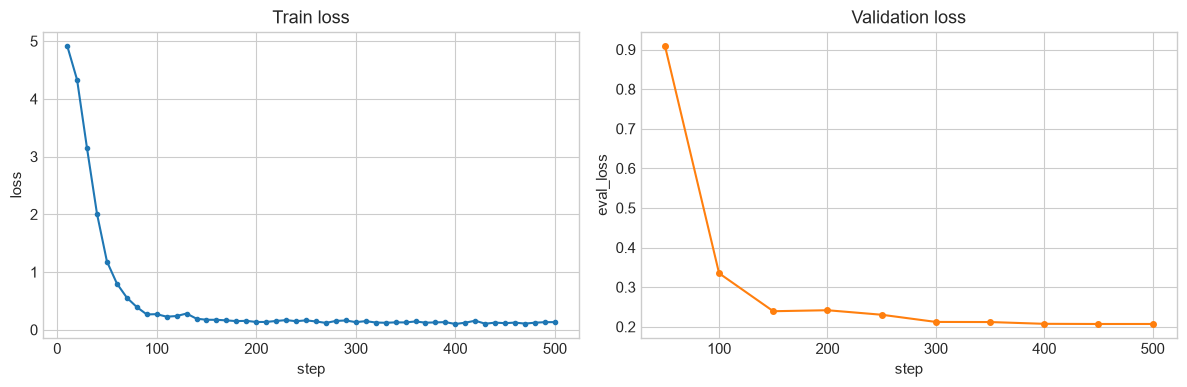

,metrica,valor
0,epochs,8
1,global_step,504
2,best_eval_loss,0.206847
3,best_checkpoint,C:\Users\Niccolas\Downloads\TrabalhoDetecaoObj...
4,train_loss_final,0.132


In [5]:
def latest_trainer_state(adapter_path: Path) -> Path | None:
    checkpoints = sorted(adapter_path.glob("checkpoint-*/trainer_state.json"))
    if checkpoints:
        return checkpoints[-1]
    root_state = adapter_path / "trainer_state.json"
    return root_state if root_state.exists() else None

trainer_state_path = latest_trainer_state(adapter_dir)
print(f"trainer_state: {trainer_state_path or 'nao encontrado'}")

if trainer_state_path and trainer_state_path.exists():
    state = json.loads(trainer_state_path.read_text(encoding="utf-8"))
    history = state["log_history"]
    train_logs = [x for x in history if "loss" in x and "eval_loss" not in x]
    eval_logs = [x for x in history if "eval_loss" in x]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot([x["step"] for x in train_logs], [x["loss"] for x in train_logs], marker="o", ms=3)
    axes[0].set_title("Train loss"); axes[0].set_xlabel("step"); axes[0].set_ylabel("loss")
    axes[1].plot([x["step"] for x in eval_logs], [x["eval_loss"] for x in eval_logs], color="C1", marker="o", ms=4)
    axes[1].set_title("Validation loss"); axes[1].set_xlabel("step"); axes[1].set_ylabel("eval_loss")
    plt.tight_layout(); plt.show()

    display(pd.DataFrame({
        "metrica": ["epochs", "global_step", "best_eval_loss", "best_checkpoint", "train_loss_final"],
        "valor": [state.get("num_train_epochs"), state.get("global_step"), state.get("best_metric"),
                  state.get("best_model_checkpoint"), train_logs[-1]["loss"] if train_logs else None],
    }))

## 6. Métricas — o que reportar na entrega TCC

| Métrica | Definição | Interpretação |
|---------|-----------|---------------|
| **Exact match** | pred == ref (string `completo`) | Acurácia estrita — exige vírgula e zeros corretos |
| **1 − CER** | 1 − (Levenshtein / len) | Proximidade caractere a caractere; costuma ser maior que exact match |
| **Acurácia fabricante/estado** | acertos / total | Classificação categórica por amostra |
| **F1 macro** | média por classe | Penaliza erros em classes raras (ex.: *embacado*, marcas minoritárias) |
| **Parse JSON** | resposta parseável | Baseline Florence-2 não gera JSON válido nesta tarefa |

> **Não confundir:** acurácia por caractere e exact match medem coisas diferentes — veja a tabela da seção 9.

In [6]:
crop_paths = sorted(p for p in crops_dir.glob("*.jpg") if p.stem in gt)
if EVAL_LIMIT > 0:
    crop_paths = crop_paths[:EVAL_LIMIT]
print(f"Avaliando {len(crop_paths)} amostras do split {SPLIT}")

Avaliando 72 amostras do split test


## 7. Baseline — Florence-2 **sem** LoRA

O modelo base **não foi treinado** para JSON de hidrômetro. Esperamos parse 0% e CER=1,0.

In [7]:
baseline_vlm = VLMInference(use_adapter=False)
baseline_rows = run_vlm_evaluation(baseline_vlm, crop_paths, gt)
baseline_metrics = compute_metrics(baseline_rows)

display(pd.DataFrame(metrics_summary_table(baseline_metrics)))

`torch_dtype` is deprecated! Use `dtype` instead!
W0703 23:53:15.795000 74180 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


,métrica,valor,descrição
0,Amostras avaliadas,72,Total de crops com ground truth
1,Taxa de JSON válido (parse),0.0%,Predições que geraram JSON estruturado
2,Acurácia exata da leitura (exact match),0.0%,Leitura.completo idêntica ao ground truth
3,Acurácia por caractere (1 - CER),0.0%,Proximidade caractere a caractere do visor
4,CER completo,100.0%,Character Error Rate (menor = melhor)
5,Acurácia fabricante,0.0%,Classificação correta da marca/placa
6,Precisão fabricante (macro),0.0%,Média macro de precisão por classe
7,Acurácia estado,0.0%,Classificação correta do estado do visor
8,Precisão estado (macro),0.0%,Média macro de precisão por classe
9,F1 fabricante (macro),0.0%,Balanceamento precisão/recall por fabricante


## 8. Pós-treino — Florence-2 **com** adaptador QLoRA

Carrega pesos de `artifacts/lora_adapter/` (melhor checkpoint por eval_loss).

In [8]:
finetuned_vlm = VLMInference(adapter_dir=adapter_dir)
finetuned_rows = run_vlm_evaluation(finetuned_vlm, crop_paths, gt)
finetuned_metrics = compute_metrics(finetuned_rows)

display(pd.DataFrame(metrics_summary_table(finetuned_metrics)))

,métrica,valor,descrição
0,Amostras avaliadas,72,Total de crops com ground truth
1,Taxa de JSON válido (parse),100.0%,Predições que geraram JSON estruturado
2,Acurácia exata da leitura (exact match),38.9%,Leitura.completo idêntica ao ground truth
3,Acurácia por caractere (1 - CER),79.0%,Proximidade caractere a caractere do visor
4,CER completo,21.0%,Character Error Rate (menor = melhor)
5,Acurácia fabricante,97.2%,Classificação correta da marca/placa
6,Precisão fabricante (macro),73.5%,Média macro de precisão por classe
7,Acurácia estado,97.2%,Classificação correta do estado do visor
8,Precisão estado (macro),48.6%,Média macro de precisão por classe
9,F1 fabricante (macro),73.8%,Balanceamento precisão/recall por fabricante


## 9. Comparação baseline vs pós-treino (%)

Tabela consolidada para o avaliador do TCC.

In [10]:
keys = [
    "parse_success_rate", "exact_match_rate", "reading_char_accuracy",
    "accuracy_fabricante", "accuracy_estado", "f1_fabricante_macro", "f1_estado_macro",
]
labels = {
    "parse_success_rate": "Parse JSON válido",
    "exact_match_rate": "Exact match (leitura)",
    "reading_char_accuracy": "Acurácia por caractere (1−CER)",
    "accuracy_fabricante": "Acurácia fabricante",
    "accuracy_estado": "Acurácia estado",
    "f1_fabricante_macro": "F1 fabricante (macro)",
    "f1_estado_macro": "F1 estado (macro)",
}

comparison = []
for k in keys:
    b = baseline_metrics.get(k, 0)
    f = finetuned_metrics.get(k, 0)
    comparison.append({
        "métrica": labels[k],
        "baseline": f"{b*100:.1f}%",
        "pós_treino": f"{f*100:.1f}%",
        "ganho": f"{(f-b)*100:+.1f} pp",
    })
display(pd.DataFrame(comparison))

report_path = resolve_path("reports") / "notebook_comparison_test.json"
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(json.dumps({
    "split": SPLIT, "samples": len(crop_paths),
    "baseline_metrics": baseline_metrics, "finetuned_metrics": finetuned_metrics,
    "comparison_table": comparison,
}, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Relatório salvo: {report_path}")

,métrica,baseline,pós_treino,ganho
0,Parse JSON válido,0.0%,100.0%,+100.0 pp
1,Exact match (leitura),0.0%,38.9%,+38.9 pp
2,Acurácia por caractere (1−CER),0.0%,79.0%,+79.0 pp
3,Acurácia fabricante,0.0%,97.2%,+97.2 pp
4,Acurácia estado,0.0%,97.2%,+97.2 pp
5,F1 fabricante (macro),0.0%,73.8%,+73.8 pp
6,F1 estado (macro),0.0%,49.3%,+49.3 pp


Relatório salvo: C:\Users\Niccolas\Downloads\TrabalhoDetecaoObjetos\vit-tcc-qlora-hidrometro\reports\notebook_comparison_test.json


## 10. Auditoria de labels

Verifica consistência entre `inteiro` e a parte inteira de `completo` em todo o dataset SFT. A célula abaixo lê `reports/label_audit.json` (gerado por `scripts/06_audit_labels.py`).

In [11]:
audit_path = resolve_path("reports") / "label_audit.json"
if not audit_path.exists():
    import subprocess
    subprocess.run([sys.executable, "scripts/06_audit_labels.py"], check=False)

if audit_path.exists():
    audit = json.loads(audit_path.read_text(encoding="utf-8"))
    display(Markdown(
        f"**Consistência dos labels:** {audit['consistency_rate']*100:.1f}% "
        f"({audit['inconsistent']} inconsistentes em {audit['total_records']})"
    ))
    if audit["issues"]:
        display(pd.DataFrame(audit["issues"][:10]))
else:
    print("Execute: python scripts/06_audit_labels.py")

**Consistência dos labels:** 100.0% (0 inconsistentes em 719)

## 11. Exemplos qualitativos

Amostras onde o QLoRA mais reduziu o CER vs baseline.

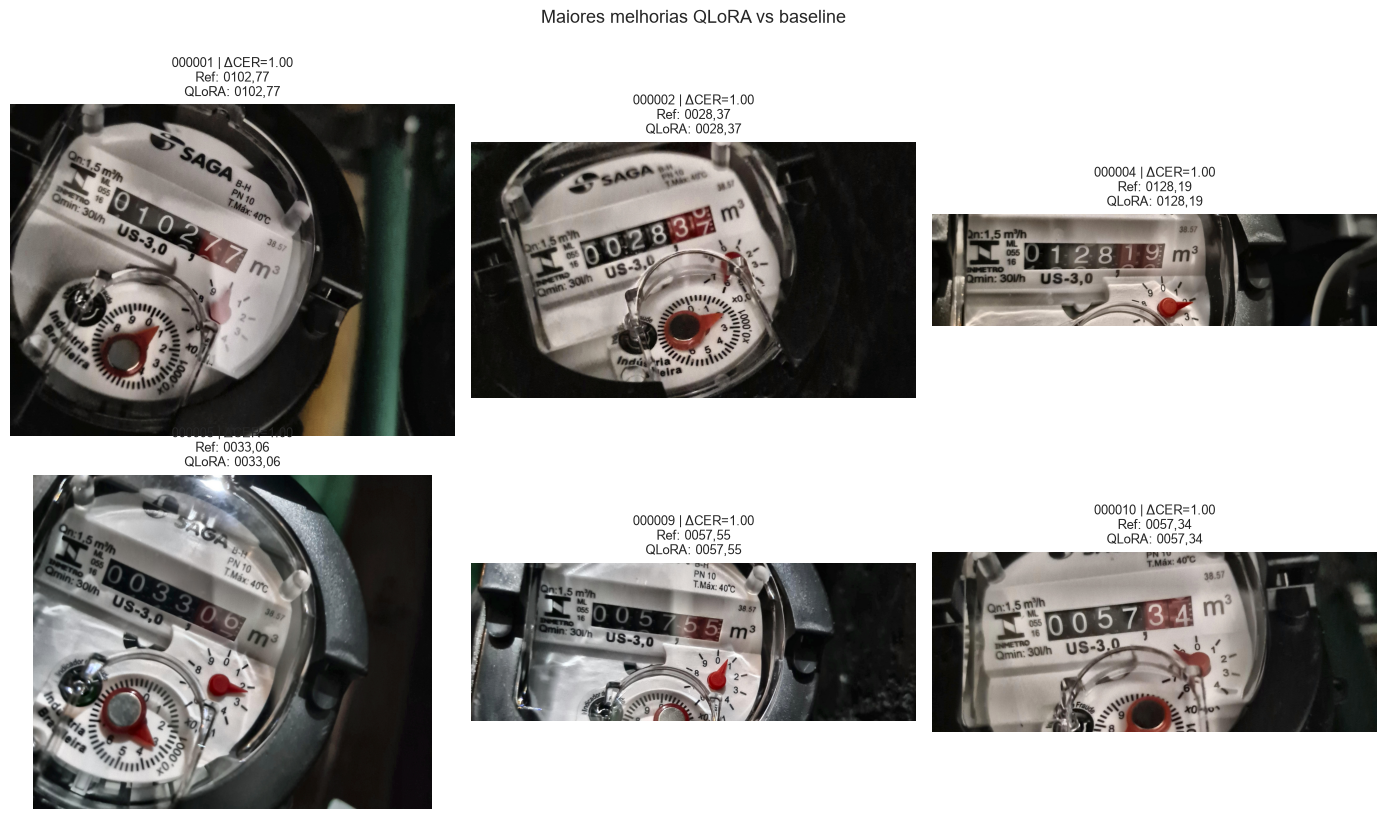

In [12]:
from hidrometro.preprocessing.io import imread_unicode

b_map = {r.stem: r for r in baseline_rows}
f_map = {r.stem: r for r in finetuned_rows}
deltas = [(s, b_map[s].cer - f_map[s].cer) for s in b_map if s in f_map]
deltas.sort(key=lambda x: x[1], reverse=True)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (stem, delta) in zip(axes.flat, deltas[:6]):
    img = imread_unicode(crops_dir / f"{stem}.jpg")
    if img is not None:
        ax.imshow(img[:, :, ::-1])
    b, f = b_map[stem], f_map[stem]
    ax.set_title(f"{stem} | ΔCER={delta:.2f}\nRef: {b.ref_completo}\nQLoRA: {f.hyp_completo}", fontsize=9)
    ax.axis("off")
plt.suptitle("Maiores melhorias QLoRA vs baseline", y=1.02)
plt.tight_layout(); plt.show()

In [13]:
def pct(value: float) -> str:
    return f"{value * 100:.1f}%"

fm = finetuned_metrics
bm = baseline_metrics
n = fm.get("samples", len(crop_paths))

audit_note = ""
audit_path = resolve_path("reports") / "label_audit.json"
if audit_path.exists():
    audit = json.loads(audit_path.read_text(encoding="utf-8"))
    rate = audit["consistency_rate"] * 100
    inconsistent = audit["inconsistent"]
    if inconsistent == 0:
        audit_note = (
            f"Os labels validados estão **{rate:.1f}% consistentes** "
            f"({audit['total_records']} registros); o gargalo de exact match "
            "não vem de erro de schema, e sim da dificuldade da leitura caractere a caractere."
        )
    else:
        audit_note = (
            f"Há **{inconsistent} labels inconsistentes** ({rate:.1f}% de consistência), "
            "o que pode limitar o teto de exact match."
        )

emb_support = fm.get("estado_report", {}).get("embacado", {}).get("support", 0)
f1_estado = fm.get("f1_estado_macro", 0)

summary = f"""## 12. Resumo executivo para avaliação

### Principais percentuais (split {SPLIT}, {n} amostras)

| Métrica | Baseline | Pós-treino QLoRA |
|---------|----------|------------------|
| Parse JSON válido | {pct(bm.get('parse_success_rate', 0))} | {pct(fm.get('parse_success_rate', 0))} |
| Exact match (leitura) | {pct(bm.get('exact_match_rate', 0))} | {pct(fm.get('exact_match_rate', 0))} |
| Acurácia por caractere (1−CER) | {pct(bm.get('reading_char_accuracy', 0))} | {pct(fm.get('reading_char_accuracy', 0))} |
| Acurácia fabricante | {pct(bm.get('accuracy_fabricante', 0))} | {pct(fm.get('accuracy_fabricante', 0))} |
| Acurácia estado | {pct(bm.get('accuracy_estado', 0))} | {pct(fm.get('accuracy_estado', 0))} |
| F1 fabricante (macro) | {pct(bm.get('f1_fabricante_macro', 0))} | {pct(fm.get('f1_fabricante_macro', 0))} |
| F1 estado (macro) | {pct(bm.get('f1_estado_macro', 0))} | {pct(fm.get('f1_estado_macro', 0))} |

### Conclusão

O fine-tuning QLoRA transforma o Florence-2 base — que **não produz JSON válido** nesta tarefa ({pct(bm.get('parse_success_rate', 0))} de parse) — em um leitor funcional com **{pct(fm.get('parse_success_rate', 0))}** de respostas estruturadas.

Na leitura do visor, o modelo atinge **{pct(fm.get('reading_char_accuracy', 0))}** de acurácia por caractere, porém **{pct(fm.get('exact_match_rate', 0))}** de exact match: a segunda métrica exige a string `completo` idêntica, incluindo zeros à esquerda e vírgula.

Fabricante e estado são classificados corretamente em **{pct(fm.get('accuracy_fabricante', 0))}** e **{pct(fm.get('accuracy_estado', 0))}** das amostras. O F1 macro de estado ({pct(f1_estado)}) permanece moderado porque a classe *embacado* tem apenas {int(emb_support)} amostras no teste — a acurácia por amostra é alta, mas o F1 macro penaliza classes raras.

{audit_note}

**Perspectivas:** ampliar dados de classes minoritárias, augmentation no crop e testes com LoRA r=32.
"""

display(Markdown(summary))



## 12. Resumo executivo para avaliação

### Principais percentuais (split test, 72 amostras)

| Métrica | Baseline | Pós-treino QLoRA |
|---------|----------|------------------|
| Parse JSON válido | 0.0% | 100.0% |
| Exact match (leitura) | 0.0% | 38.9% |
| Acurácia por caractere (1−CER) | 0.0% | 79.0% |
| Acurácia fabricante | 0.0% | 97.2% |
| Acurácia estado | 0.0% | 97.2% |
| F1 fabricante (macro) | 0.0% | 73.8% |
| F1 estado (macro) | 0.0% | 49.3% |

### Conclusão

O fine-tuning QLoRA transforma o Florence-2 base — que **não produz JSON válido** nesta tarefa (0.0% de parse) — em um leitor funcional com **100.0%** de respostas estruturadas.

Na leitura do visor, o modelo atinge **79.0%** de acurácia por caractere, porém **38.9%** de exact match: a segunda métrica exige a string `completo` idêntica, incluindo zeros à esquerda e vírgula.

Fabricante e estado são classificados corretamente em **97.2%** e **97.2%** das amostras. O F1 macro de estado (49.3%) permanece moderado porque a classe *embacado* tem apenas 2 amostras no teste — a acurácia por amostra é alta, mas o F1 macro penaliza classes raras.

Os labels validados estão **100.0% consistentes** (719 registros); o gargalo de exact match não vem de erro de schema, e sim da dificuldade da leitura caractere a caractere.

**Perspectivas:** ampliar dados de classes minoritárias, augmentation no crop e testes com LoRA r=32.
